## Preliminary Thoughts
- Our project will be focused on weather conditions during NFL games and creating an index that will display how ideal the current conditions are for playing.
- Weather Conditions that will be focused on:
  - Rain
  - Snow
  - Temperature
  - Wind
  - Wind Chill
  - Heat Index 

# U.S. Map

In [8]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask


fname = 'PITCLE2'
path = f"/home/taf5578/meteo473/sp26_groupwork/473_sp26_group9/data/{fname}.nc"
gamedata = xr.open_dataset(path)
gamedata

FileNotFoundError: [Errno 2] No such file or directory: '/home/taf5578/meteo473/sp26_groupwork/473_sp26_group9/data/PITCLE2.nc'

In [9]:
ts = gamedata.valid_time.values
gd96 = gamedata.sel(valid_time=ts[16])

initial_datetime = pd.to_datetime(gamedata.valid_time.values[0])
initial_time = initial_datetime.strftime("%Hz %a %b %d %Y")
valid_datetime = pd.to_datetime(gamedata.valid_time.values[16])
valid_time = valid_datetime.strftime("%Hz %a %b %d %Y")

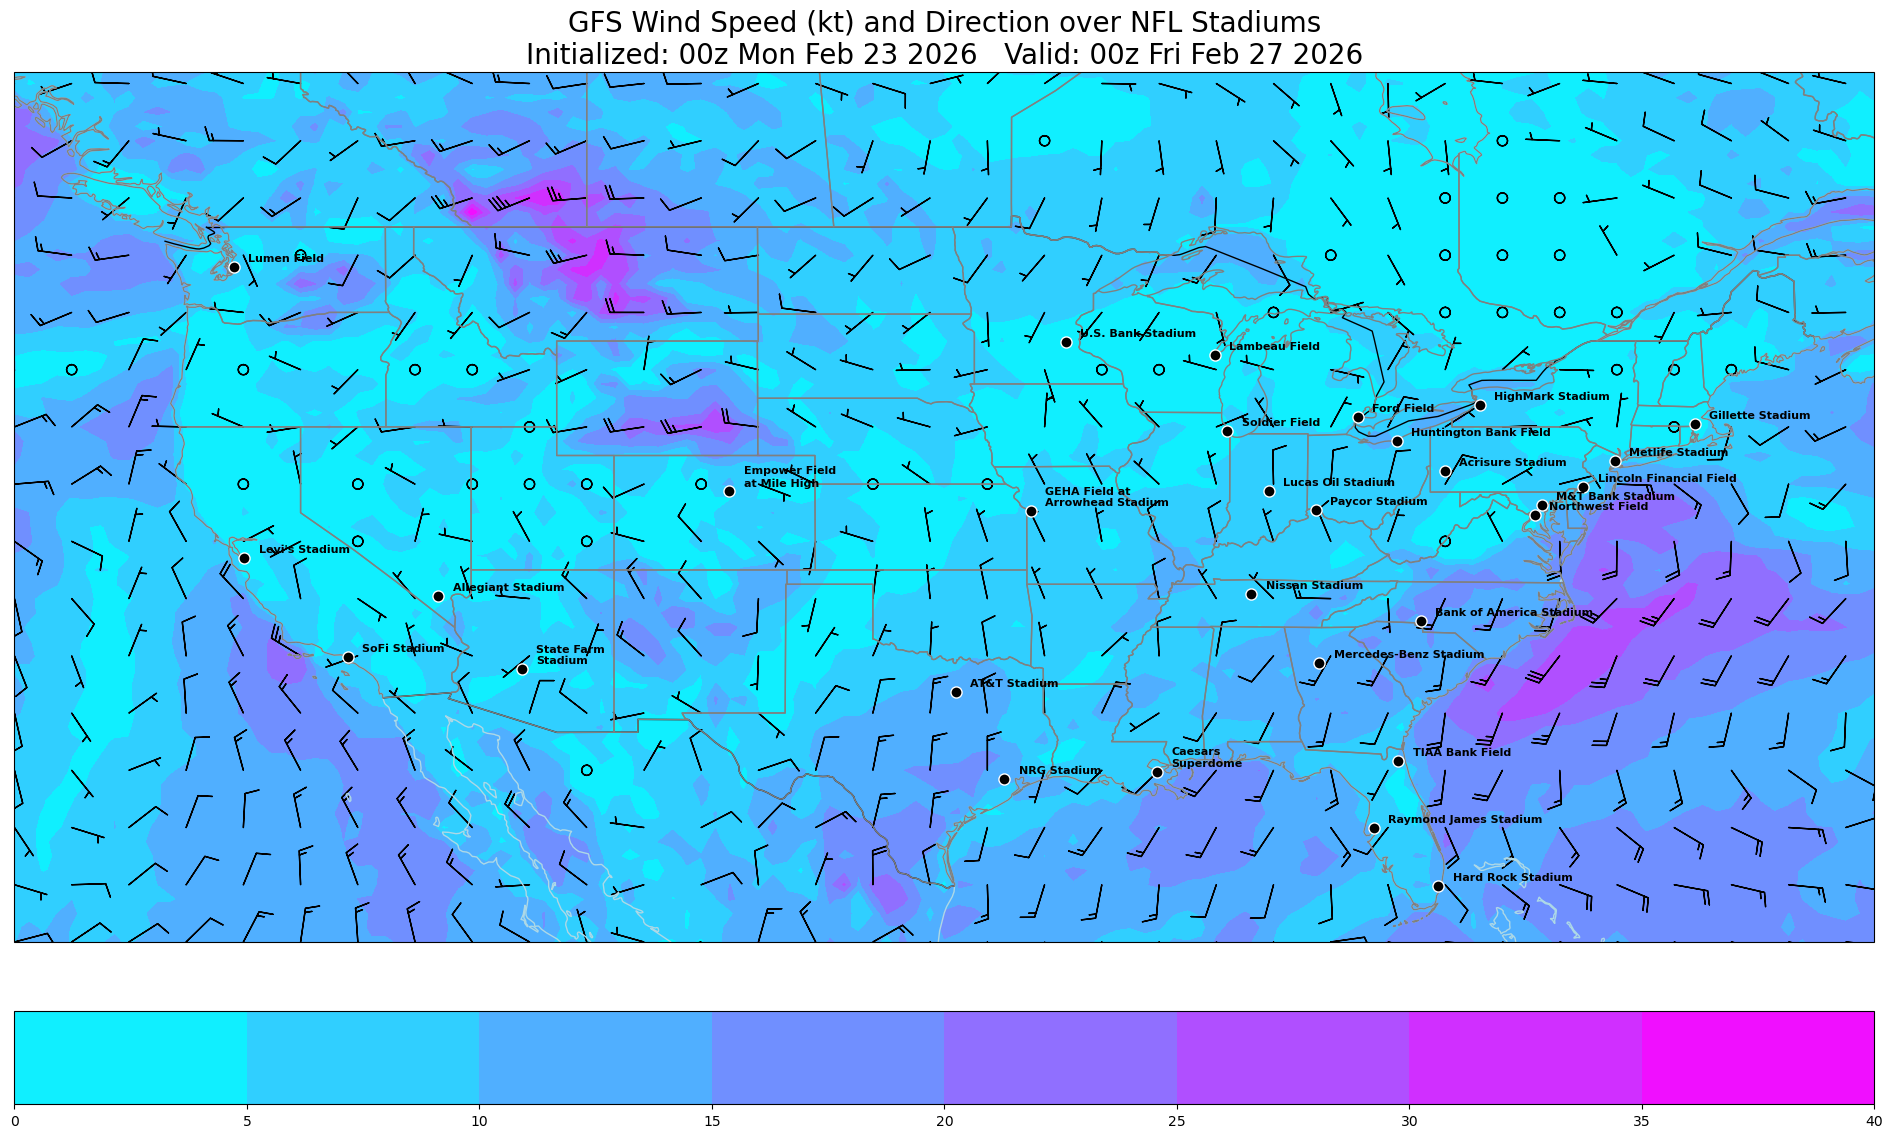

In [10]:
# Imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import pandas as pd
import io
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

# Create the base map
def makebasemap():
    fig = plt.figure(figsize=(24,18))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-130, -65, 24, 50])  # CONUS
    ax.add_feature(cfeature.COASTLINE, edgecolor='lightblue')
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, edgecolor='gray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

#****CODE TO PLOT THE STADIUM NAMES****

# Coordinates for every NFL Stadium
    Stadiums = {
        'State Farm\nStadium': (33.5276, -112.2626),
        'Mercedes-Benz Stadium': (33.7550, -84.4008),
        'M&T Bank Stadium': (39.2779, -76.6227),
        'HighMark Stadium': (42.7738, -78.7868),
        'Bank of America Stadium': (35.2251, -80.8529),
        'Soldier Field': (41.8623, -87.6167),
        'Paycor Stadium': (39.0954, -84.5160),
        'Huntington Bank Field': (41.5061, -81.6995),
        'AT&T Stadium': (32.7473, -97.0945),
        'Empower Field\nat Mile High': (39.7439, -105.0201),
        'Ford Field': (42.3400, -83.0456),
        'Lambeau Field': (44.5013, -88.0622),
        'NRG Stadium': (29.6847, -95.4107),
        'Lucas Oil Stadium': (39.7601, -86.1639),
        'TIAA Bank Field': (30.3239, -81.6373),
        'GEHA Field at\nArrowhead Stadium': (39.0489, -94.4849),
        'Allegiant Stadium': (36.0908, -115.1830),
        'SoFi Stadium': (33.9535, -118.3392),
        'Hard Rock Stadium': (25.9580, -80.2389),
        'U.S. Bank Stadium': (44.9738, -93.2575),
        'Gillette Stadium': (42.0909, -71.2643),
        'Caesars\nSuperdome': (29.9511, -90.0812),
        'Metlife Stadium': (40.8135, -74.0745),
        'Lincoln Financial Field': (39.9008, -75.1675),
        'Acrisure Stadium': (40.4468, -80.0158),
        "Levi's Stadium": (37.4030, -121.9700),
        'Lumen Field': (47.5952, -122.3316),
        'Raymond James Stadium': (27.9759, -82.5033),
        'Nissan Stadium': (36.1665, -86.7713),
        'Northwest Field': (38.9078, -76.8644),
    }

# Plot stadiums
    for stadium, (lat, lon) in Stadiums.items():
        ax.plot(lon, lat, marker='o', color='black', markersize=8,
                markeredgecolor='white', transform=ccrs.PlateCarree())
        ax.text(lon + 0.5, lat + 0.2, stadium, fontsize=8,
                fontweight='bold', transform=ccrs.PlateCarree())
    return fig, ax

#Create variables for the u component and v component of the wind directions
u10 = gd96["u10"]*1.94384 # Converts m/s to kts
v10 = gd96["v10"]*1.94384

# Convert wind from u and v component vectors into a magnitude 
wind_spd = np.sqrt(u10**2 + v10**2)


fig, ax = makebasemap() #Creates a map
wind_spd_plot = ax.contourf(gd96["longitude"], gd96["latitude"], wind_spd, levels=np.arange(0, 45, 5), cmap='cool', transform=ccrs.PlateCarree()) # Plots the colormap for wind speed intervals of 5 kts from 0 kts to 70 kts
plt.colorbar(wind_spd_plot, ax = ax, orientation = "horizontal", pad = 0.05) # Adds a colorbar below the map to label the wind speed values for each color

# Add wind barbs to the map and reduce the total amount of wind barbs shown
# I used AI to figure out how to reduce the amount because the regrid_shape function didn't work
skip = 4
ax.barbs(gd96["longitude"][::skip], gd96["latitude"][::skip], u10[::skip, ::skip], v10[::skip, ::skip], linewidth=1, length=7, transform=ccrs.PlateCarree())

# Add title with imported initial and valid times
plt.title(f"GFS Wind Speed (kt) and Direction over NFL Stadiums\nInitialized: {initial_time}   Valid: {valid_time}", fontsize=20)
plt.show()


## Station Model of Cleveland, OH
![Alt text](StationModel.png)

The map gives an overview of what the surface conditions were like all across continguous United States at 00Z on Friday November 22, 2024  (7:00 p.m. EST November 21, 2024), but this is a zoomed in version of that map. The Cleveland, OH station model is indicated by the blue square.
- The station model shows us:
  - Temperatures (indicated by the red number on the top left)
     - Temperature during the game was 34 °F
        - Ignore the red 31 on the bottom right as that shows the temperature from a different station model
  - Dew Point Temperatures (indicated by the green number on the bottom left)
     - Dew Point Temperature was 34 °F
  - Wind Speed (in knots) and Direction (indicated by the line attached to the circle)
     - Wind Speed was 20 knots and the direction coming from the ESE
  - Pressure (last three digits and then add either 9 or 10 before those digits to get the pressure in mb)
     - Unless if there is a hurricane or a generational storm system (neither of which apply here), add 10 if the first digit is anywhere from 0-4
     - Therefore the pressure was 1004.2 mb

## Radar Image during the game
![Alt text](Radar.png)
This map shows the radar in Northern Ohio at 0000 UTC (00Z) on November 22, 2024. Around Cleveland, the radar shows blue and green colors indicating light precipitation during this timeframe. It tells us that there was precipitation falling down during the Steelers vs. Browns game.

## Storms Events Database
![Alt text](StormEventsDatabase.png)

This is a description of what happened during November 21 and 22, 2024 in Cuyahoga County (Cleveland is inside this county). It helps to explain why snowfall occurred and what impacts the area saw. Traffic was less than optimal, so going to and from the game was difficult for commuters.

# Milestone 2

## Target Audience for the Index
Our target audience for our index includes:
- NFL players in order for them to prepare for their game
- Stadium managers so they know when the best times to maintain the stadium's grass/turf are
- Spectators to prepare for the conditions before heading into a stadium or driving there

## Threat Index: Weather during NFL Games
- Range: 0 to 100
- 0 = Best weather conditions
- 100 = Worst weather conditions

Best possible conditions:
- Apparent (Feels Like) Temperature between 50 °F and 75 °F
- Wind Speeds less than 5 miles per hour
- No precipitation

Weighting
- Apparent Temperature: 25%
- Wind Speed: 25% 
- Precipitation: 50%

## How the Formula Works
We initally used an Index Scale from 0-20
- Apparent Temperature (Index from 0 to 5):
  - Heat Index
    - Any apparent (feels like) temperature from 50 °F to 75 °F has an Index of 0 and a rate of 0
    - From 75 °F to less than 85 °F, the Index begins at 0 and approaches 1, but does not reach exactly 1 (The range starts at 75 °F, but 75 °F equals 0)
      - The formula for this range is apparent temperature (fl) minus 75, and then divided by 10)
      - Every degree increases leads to the Index increasing by 0.1
        - Example 80 °F has an Index of 0.5
    - From 85 °F to less than 105 °F, Index starts at 1 and approaches 5, but does not reach exactly 5
      - The formula for this range is add 1 at the beginning since the Index starts at 1, then the apparent temperature (fl) is subtracted by 85, and then divided by 5 after that
      - Every degree increases leads to the Index increasing by 0.2 Example 95°F has an Index of 3
        - Example 95°F has an Index of 3
        - The reason for the higher rate of increase is because a feels like of 85 °F compared to 90 °F or a feels like of 95 °F compared to 100 °F feels more intense in contrast to a feels like of 75 °F compared to 80 °F
    - Any apparent temperature at 105°F or greater has an Index of 5
      - This means the rate of the index increasing is 0
   - Wind Chill
     - From 50 °F to greater than 0 °F, Index begins at 0 and approaches 5, but does not reach exactly 5
       - Formula is 50°F minus the apparent temperature, and then divide by 10
       - This means the Index increases by 0.1 for every degree the apparent temperature drops
         - Example 35 degrees has an Index of 1.5
    - Any apparent temperature at 0 °F or lower has an index of 5 with a rate of 0
##
- Wind Speed (Index from 0 to 5):
  - Any wind speed from 0 mph to 5 mph has both an Index and rate of 0
  - From 5 mph to less than 20 mph, the Index begins at 0 and approaches 4, but does not get to exactly 4
    - Formula for this particular range is wind speed (windmph) subtracted by 5, then divided by 2.5
    - This leads to an Index increase of 0.4 for each mph the wind speed increases
      - Ex. 10 mph = 2
  - From 20 mph to less than 30 mph, Index begins at 4 and approaches 5, but will not reach exactly 5
    - Formula for this range is windmph subtracted by 20, then divided by 10
    - Index increases by 0.1 for each mph the wind speed increases
      - Ex. 25 mph = 4.5
    - The reason the rate of increase is lower here is because the difference between 20 and 30 mph is not as substantial as the difference between a 10 mph wind and a 20 mph wind
  - Any wind speed 30 mph or greater has an Index of 5 and a rate of 0
##
- Precipitation (Max Index of Rain or Snow from 0 to 10):
  - Rain (Index from 0 to 10):
    - Rain rate of 0 in/hr will have an Index and rate of 0
    - From 0 in/hr to less than 0.4 in/hr, the Index begins at 0 and approaches 8, but does not get to 8
      - Formula for this range is rain rate (rain) divided by 0.4 (since the range is just under 0.4) and then multiplied by 8
      - Index increases by 2 for every tenth of an inch per hour increase of rain (0.2 for every hundredth inch per hour increase)
        - Ex. 0.15 in/hr = 3
    - From 0.4 in/hr to less than 0.6 in/hr, the Index begins at 8 and approaches 10, but will not reach 10
      - Formula for this range is 8 plus rain rate subtracted by 0.4 (where the range starts), then divided by 0.2 (due to the range being just under 0.2), and then multiplied by 2
      - Index increases by 1 for every 1/10 in/hr increase of rain (0.1 for every 1/100 in/hr increase)
        - Ex. 0.45 in/hr = 8.5
        - The reasoning for the lower rate is that differences in this range are not as considerable as the previous range
      - Any rain rate of 0.6 in/hr or greater has an Index of 10 and a rate of 0
  - Snow (Index from 0 to 10):
    - Snow rate of 0 in/hr will have an Index and rate of 0
    - From 0 in/hr to less than 0.1 in/hr, the Index begins at 0 and approaches 1, but does not get to 1
      - Formula for this range is snow rate (snow) divided by 0.1
      - Index increases by 1 for every tenth in/hr snow increase
        - Ex. 0.1 in/hr = 1
    - From 0.1 in/hr to less than 0.5 in/hr, the Index begins at 1 and approaches 7, but does not reach 7
      - Formula for this range is snow rate minus 0.1, then divided by 0.4, and then multiplied by 6
      - Index increases by 1.5 for every tenth in/hr snow increase
        - Ex. 0.3 in/hr = 4
        - Reasoning for the higher Index increase is because once you get to a snowfall rate of 0.1 in/hr or higher, the conditions during the game will deteriorate more quickly compared to the difference between 0 in/hr and 0.1 in/hr 
    - From 0.5 in/hr to less than 1.0 in/hr, the Index begins at 7 and approaches 10, but does not reach 10
    - Formula for this range is add 7 at first, then do snow rate minus 0.5, then divided by 0.4, and then multiplied by 3
    - Index increases by 0.6 for every 1/10 in/hr snow increase
      - Ex. 0.8 in/hr = 8.8
      - The Index rate is lower for this range because the difference in conditions does not change as much in this range compared to the previous two ranges as the snow is already coming down at a moderate rate
    - A snowfall rate of an inch per hour or greater will lead to an Index of 10 with a rate of 0
##
We were originally going to leave the scale as 0-20 but decided to multiply the entire scale by 5 to make the scale 0-100 to make it easier for our target audience to comprehend. We used a custom colormap using green, yellow, orange, and red. Green indicates a good index, yellow indicates a fair index, orange indicates a harsh index, and red indicates an extremely harsh index. We used these colors because the connotation behind each makes sense (for example green is good, red is bad).

## Reasoning for Choosing the Variables
In our code, we decided to use these variables:
- 2 meter temperature (t2m)
  - Important for calculating both the wind chill and the heat index in the apparent temperature category
  - We had to convert this from Celsius to Fahrenheit and decided to make this change to make the units easier for the general audience to understand
  - The value of knowing the 2 meter air temperature is that players need to know the temperature in order to know how to approach their warm-ups
- 10-meter Wind Components in the u and v directions (u10 and v10)
    - Gives the magnitude and the direction of wind speeds in the u direction and in the v direction
    - We used Numpy to combine the u and v wind components into a single wind vector
      - Even though it is a wind vector, the index only takes into account the magnitude of these vectors
    - The wind speed was originally in meters per second (m/s) so we had to convert that to miles per hour (mph) to make the units more recognizable for the audience
    - Needed to measure the wind speed category as well as the wind chill in the apparent temperature category
    - Useful to measure how fast the winds will be during the game for the quarterback throwing the ball as well as the kickers and punters when they kick the ball
- Relative Humidity (r2)
  - We used relative humidity to help us measure the heat index (hot apparent temperatures)
  - Gives an idea of how saturated the air is at a specific time
  - During games at which temperatures are high, relative humidity can play a big role into how quickly players get fatigued due to the muggy conditions
- Precipitation rate (prate)
  - Helps to determine how intense precipitation is falling at a specific time
- Rain (crain)
  - We chose rainfall as an indicator for how slippery field conditions will be during the game and how dreary the conditions will be for the spectators
  - We had to convert this from millimeters per second (mm/s) to inches per hour (in/hr)
- Snow (csnow)
  - We also choose snowfall not only as an indicator for how field conditions will be, but also how bad driving conditions will be for spectators that go to the game
  - We converted this from mm/s to in/hr and multiplied by 10 afterwards to give a 10:1 snow to liquid ratio

Tyler

In [2]:
tempF = (gd96['t2m']- 273.15) * 9/5 + 32

# Grabbing wind speed from data and converting to mph
windms = np.sqrt(gd96['u10']**2+gd96['v10']**2)
windmph=windms*2.237

# Calculating wind chill 
wc = (35.7 + 0.6215 * tempF - 35.75 * (windmph ** 0.16) + 0.4275 * tempF * (windmph ** 0.16))

# Only applying wind chill to areas with temperatures uner 50F and wind > 3 mph
# AI was used to discover the xr.where() function, and format was replicated in the next cell
wctemp = xr.where((tempF <= 50) & (windmph >= 3), wc, tempF)

# Pulling relative humidity data and calculating heat index from NWS formula
rh = gd96['r2']
hi = (-42.379 + 2.04901523 * tempF + 10.14333127 * rh - 0.22475541 * tempF * rh - 0.00683783 * tempF**2 - 0.05481717 * rh**2 + 0.00122874 * tempF**2 * rh +  0.00085282 * tempF * rh**2 - 0.00000199 * tempF**2 * rh**2)

# NWS formula contains adjustments under certain conditions; these were applied accordingly
# Adjustment for when T is between 80F and 112F and RH < 13%
adj1 = ((13 - rh) / 4) * np.sqrt(np.maximum(0, (17 - np.abs(tempF - 95.)) / 17))
hi = xr.where((rh < 13) & (tempF >= 80) & (tempF <= 112), hi - adj1, hi)

# Adjustment for when T is between 80F and 87F, and RH > 85%
adj2 = ((rh - 85) / 10) * ((87 - tempF) / 5)
hi = xr.where((rh > 85) & (tempF >= 80) & (tempF <= 87), hi + adj2, hi)

# Combining original heat index and both adjustments into one group
hitemp = xr.where(tempF >= 80, hi, tempF)

# Applying both wind chill and heat index to create a map of real feel
fl = xr.where(tempF <= 50, wctemp, xr.where(tempF >= 80, hitemp, tempF))

#Change the longitude range 
gamedata = gamedata.assign_coords( longitude = (((gamedata.longitude + 180) % 360) - 180))

#Assign variables to the right forecast hour (16)
rain = gamedata['prate'].isel(valid_time=16) * 141.73
snow = gamedata['prate'].isel(valid_time=16) * 141.73 * 10
lat = gamedata['latitude']
lon = gamedata['longitude']

crain = gamedata['crain'].isel(valid_time=16)
csnow = gamedata['csnow'].isel(valid_time=16)

#Rain Intensity color map (got this from AI)
colors = [
    "#00FF00",  # light green
    "#66FF00",
    "#CCFF00",
    "#FFFF00",  # yellow
    "#FFCC00",
    "#FF9900",  # orange
    "#FF4D00",
    "#FF0000",  # red
    "#CC00CC",
    "#8000FF"   # purple
]
rain_cmap = mcolors.LinearSegmentedColormap.from_list("rain_radar", colors)

def points(fl, windmph, rain, snow):

# APPARENT TEMPERATURE
# I used AI to help write the temperature contributions in xarray code since that is what we used in our original index back in milestone 1
    temp_contribution = xr.zeros_like(fl)
    mask = ((fl >= 75) & (fl < 85))
    temp_contribution = xr.where(mask, (fl - 75) / 10, temp_contribution)
    mask = ((fl >= 85) & (fl < 105))
    temp_contribution = xr.where(mask, 1 + ((fl - 85) / 5), temp_contribution)
    mask = fl >= 105
    temp_contribution = xr.where(mask, 5, temp_contribution)
    mask = ((fl < 50) & (fl > 0))
    temp_contribution = xr.where(mask, (50 - fl) / 10, temp_contribution)
    mask = fl <= 0
    temp_contribution = xr.where(mask, 5, temp_contribution)

#WIND SPEED
    wind_contribution = xr.zeros_like(windmph)
    mask = ((windmph >= 5) & (windmph < 20))
    wind_contribution = xr.where(mask, ((windmph - 5) / 2.5), wind_contribution)
    mask = ((windmph >= 20) & (windmph < 30))
    wind_contribution = xr.where(mask, 4 + ((windmph - 20) / 10), wind_contribution)
    mask = windmph >= 30
    wind_contribution = xr.where(mask, 5, wind_contribution)               

#PRECIPITATION 
    # RAIN
    rain_contribution = xr.zeros_like(rain)
    mask = ((rain > 0) & (rain < 0.4))
    rain_contribution = xr.where(mask, ((rain / 0.4) * 8), rain_contribution)
    mask = ((rain >= 0.4) & (rain < 0.6))
    rain_contribution = xr.where(mask, 8 + (((rain - 0.4) / 0.2) * 2), rain_contribution)
    mask = rain >= 0.6
    rain_contribution = xr.where(mask, 10, rain_contribution)

    # SNOW
    snow_contribution = xr.zeros_like(snow)
    mask = ((snow > 0) & (snow < 0.1))
    snow_contribution = xr.where(mask, (snow / 0.1), snow_contribution)
    mask = ((snow >= 0.1) & (snow < 0.5))
    snow_contribution = xr.where(mask, 1 + (((snow - 0.1) / 0.4) * 6), snow_contribution)
    mask = ((snow >= 0.5) & (snow < 1))
    snow_contribution = xr.where(mask, 7 + (((snow - 0.5) / 0.4) * 3), snow_contribution)
    mask = snow >= 1
    snow_contribution = xr.where(mask, 10, snow_contribution)

    # Combines the rain and snow contributions, but limits the index to only 10
    # Had to convert from xr.maximum() to np.maximum() since xr.maximum() did not work
    # Confirmed with AI that np.maximum() worked with my code
    precip_contribution = np.maximum(rain_contribution, snow_contribution)
    
    index = (temp_contribution + wind_contribution + precip_contribution)*(5)
    return index

# Creates a variable for the index to be shown on the map
index = points(fl, windmph, rain, snow)

#Create map and colorbar
fig, ax = makebasemap()
cont = ax.contourf( gd96['longitude'], gd96['latitude'], index, levels=np.arange(0, 100.5, 0.5), cmap=rain_cmap, transform=ccrs.PlateCarree())
cbar = plt.colorbar(cont, ax=ax, orientation='horizontal', pad=0.04)
cbar.set_label("Harshness Index", fontsize=14)
cbar.set_ticks(range(0, 101, 5))
plt.title(f"Weather Harshness Index Map \nInitialized: {initial_time}   Valid: {valid_time}", fontsize=20)
plt.show()

NameError: name 'gd96' is not defined

## Algorithm's Performance
- Our algorithm produced reasonable values and accurately showed which areas had the harshest conditions. Furthermore, the algorithm accurately captured the harshness of precipiation due to the fact that there was a direct correlation between higher precipitation rates and a more severe Index given to those locations.
- From the six runs, there were no false alarms since all of the map was shaded in a color indicated in the colorbar below the map.
- The only revision we made to the formula was brought up during the "How the Formula Works" markdown cell where we discussed how our Index was originally from 0-20 but we multiplied the whole scale by 5 to have an index from 0-100.